In [1]:
import pandas as pd
from IPython.display import display

test_df = pd.read_csv("BigMartSales Prediction/Test.csv")
train_df = pd.read_csv("BigMartSales Prediction/Train.csv")

display(train_df.head())
# display(train_df.info())
# display(train_df.describe())

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [2]:
import numpy as np

print(np.unique(train_df["Item_Fat_Content"]))

['LF' 'Low Fat' 'Regular' 'low fat' 'reg']


In [3]:
print(np.unique(train_df["Item_Type"]))

['Baking Goods' 'Breads' 'Breakfast' 'Canned' 'Dairy' 'Frozen Foods'
 'Fruits and Vegetables' 'Hard Drinks' 'Health and Hygiene' 'Household'
 'Meat' 'Others' 'Seafood' 'Snack Foods' 'Soft Drinks' 'Starchy Foods']


In [4]:
print(train_df["Outlet_Size"].unique())

['Medium' nan 'High' 'Small']


In [5]:
print(np.unique(train_df["Outlet_Location_Type"]))

['Tier 1' 'Tier 2' 'Tier 3']


In [6]:
print(np.unique(train_df["Outlet_Type"]))

['Grocery Store' 'Supermarket Type1' 'Supermarket Type2'
 'Supermarket Type3']


In [7]:
stats = train_df["Item_Fat_Content"].value_counts()
StatsDF = pd.DataFrame({'Item_Fat_Content':stats.index, 'Frequency':stats.values})
display(StatsDF)

,Item_Fat_Content,Frequency
0,Low Fat,5089
1,Regular,2889
2,LF,316
3,reg,117
4,low fat,112


In [8]:
train_df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [9]:
train_df.describe(include='object')

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,8523,8523,8523,8523,6113,8523,8523
unique,1559,5,16,10,3,3,4
top,FDW13,Low Fat,Fruits and Vegetables,OUT027,Medium,Tier 3,Supermarket Type1
freq,10,5089,1232,935,2793,3350,5577


0        9.300
1        5.920
2       17.500
3       19.200
4        8.930
         ...  
8518     6.865
8519     8.380
8520    10.600
8521     7.210
8522    14.800
Name: Item_Weight, Length: 8523, dtype: float64


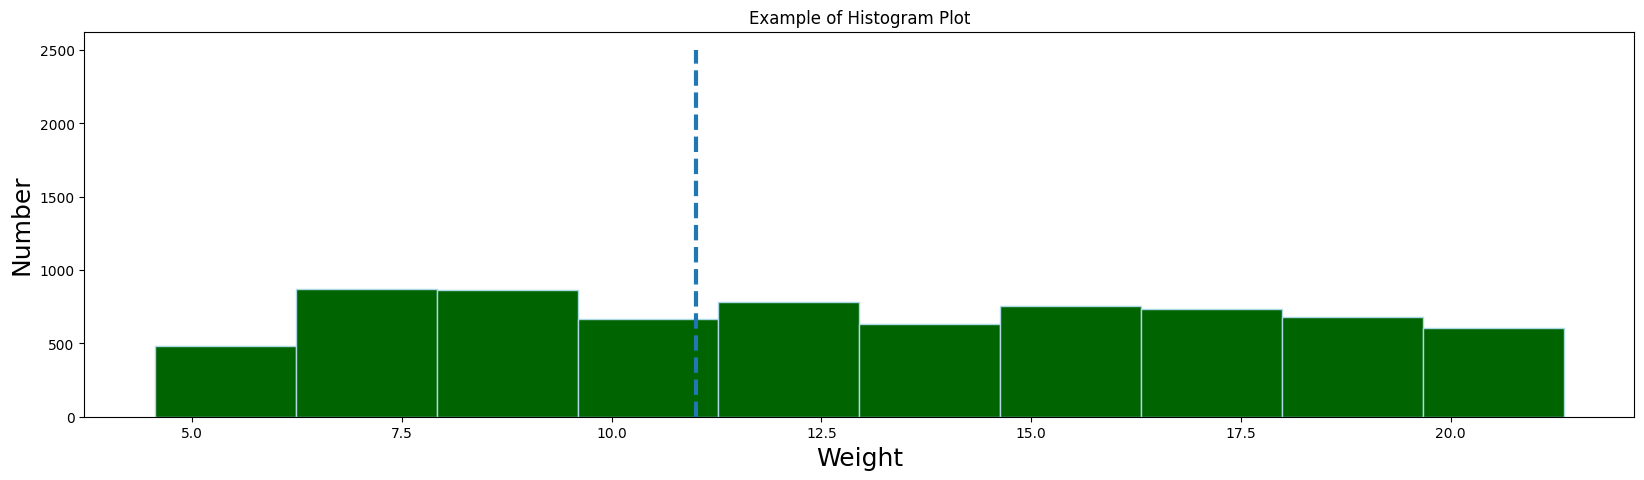

In [10]:
import matplotlib.pyplot as plt

# Plot the distribution of numpy data

print(train_df.Item_Weight)
train_df.Item_Weight.plot(
    kind="hist", edgecolor="lightblue", lw=2, color="darkgreen", figsize=(20, 5)
)
plt.plot([11, 11], [0, 2500], ls="--", lw=3)
# Add axis labels
plt.xlabel("Weight", fontsize=18)
plt.ylabel("Number", fontsize=18)
plt.title("Example of Histogram Plot")
plt.show()

0       3735.1380
1        443.4228
2       2097.2700
3        732.3800
4        994.7052
          ...    
8518    2778.3834
8519     549.2850
8520    1193.1136
8521    1845.5976
8522     765.6700
Name: Item_Outlet_Sales, Length: 8523, dtype: float64


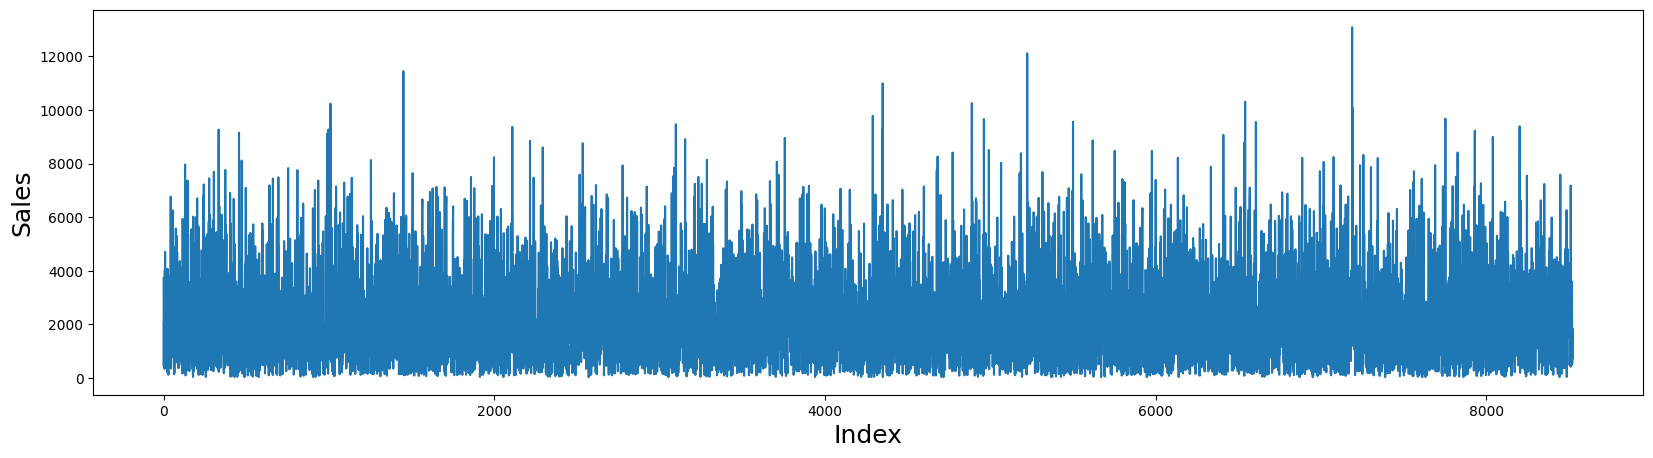

In [11]:
import seaborn as sns

plt.figure(figsize=(20, 5))
print(train_df["Item_Outlet_Sales"])
plt.plot(train_df.index, train_df["Item_Outlet_Sales"])

plt.xlabel("Index", fontsize=18)
plt.ylabel("Sales", fontsize=18)
plt.show()

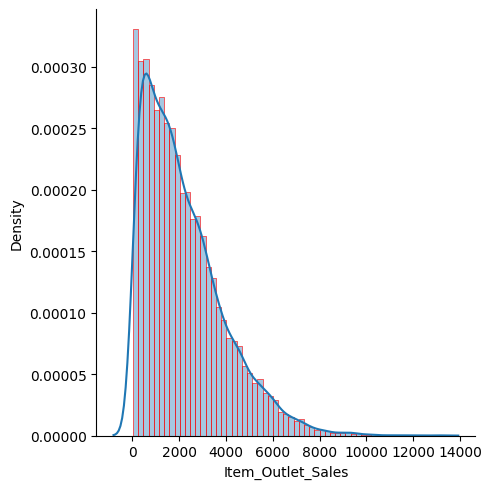

In [12]:
# sns.distplot(
#     train_df["Item_Outlet_Sales"],
#     hist_kws=dict(edgecolor="red", linewidth=2, label="distribution"),
# )
sns.displot(
    train_df["Item_Outlet_Sales"],
    kde=True,
    stat="density",
    kde_kws=dict(cut=3),
    alpha=0.4,
    edgecolor="red",
)


<Axes: xlabel='Item_Type', ylabel='count'>

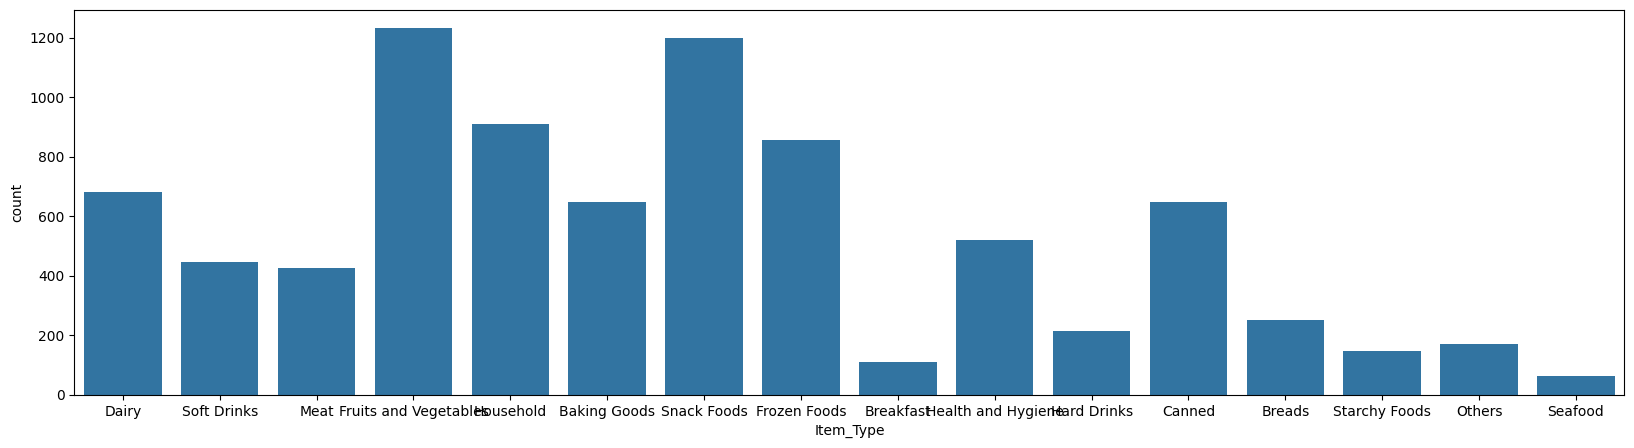

In [13]:
import seaborn as sns

plt.figure(figsize=(20, 5))
sns.countplot(x="Item_Type", data=train_df)

<Axes: xlabel='count', ylabel='Item_Fat_Content'>

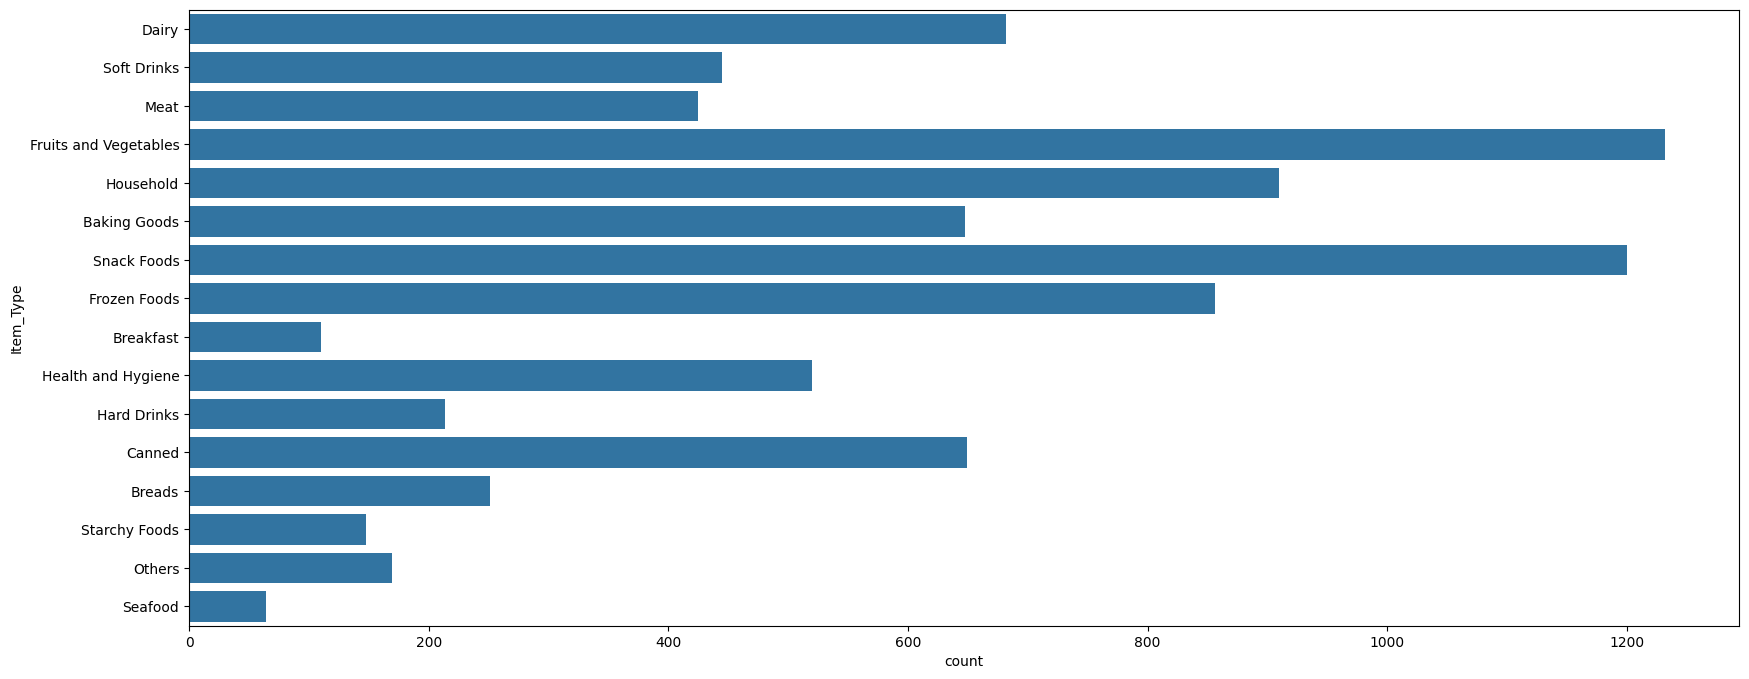

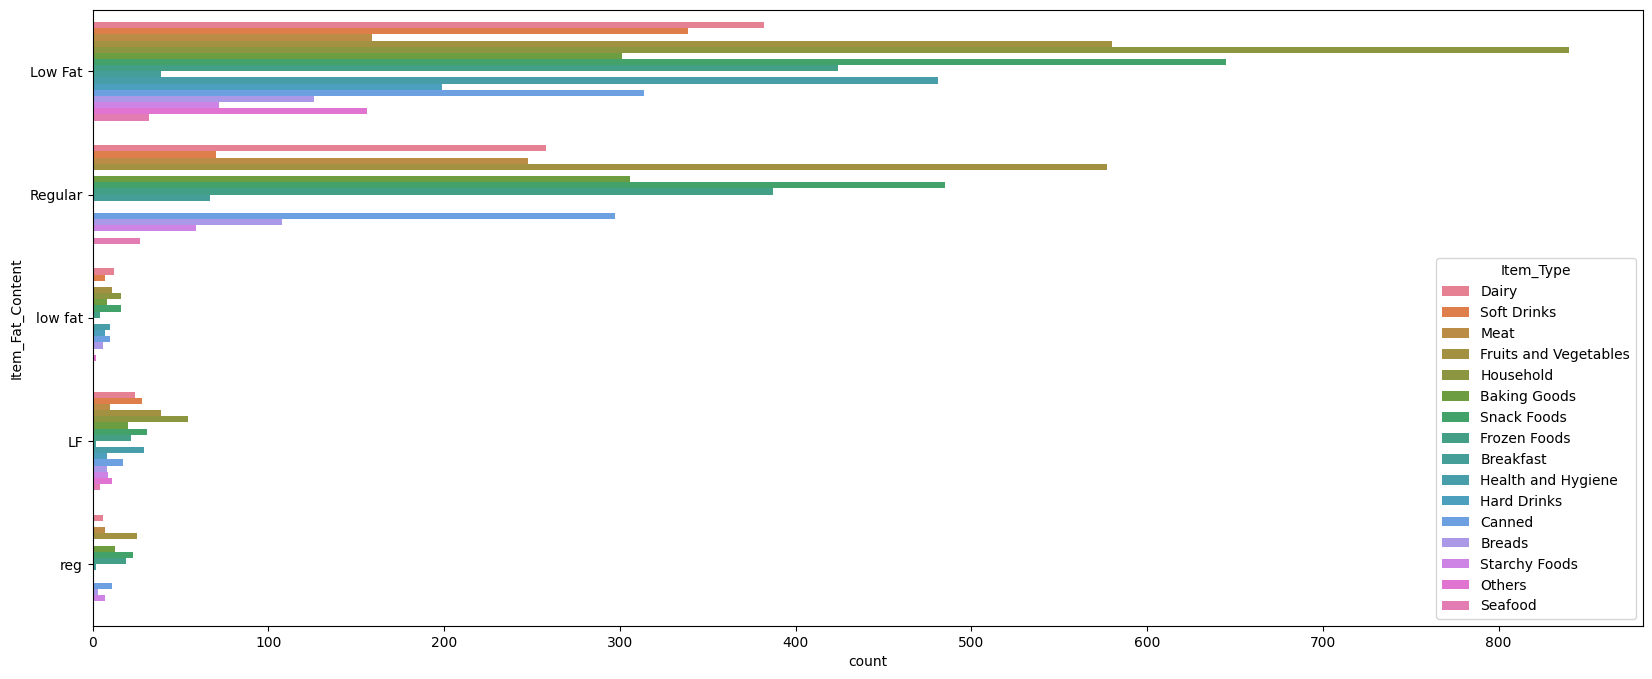

In [14]:
import seaborn as sns

plt.figure(figsize=(20, 8))
sns.countplot(y="Item_Type", data=train_df)

plt.figure(figsize=(20, 8))
sns.countplot(y="Item_Fat_Content", hue="Item_Type", data=train_df)

<Axes: >

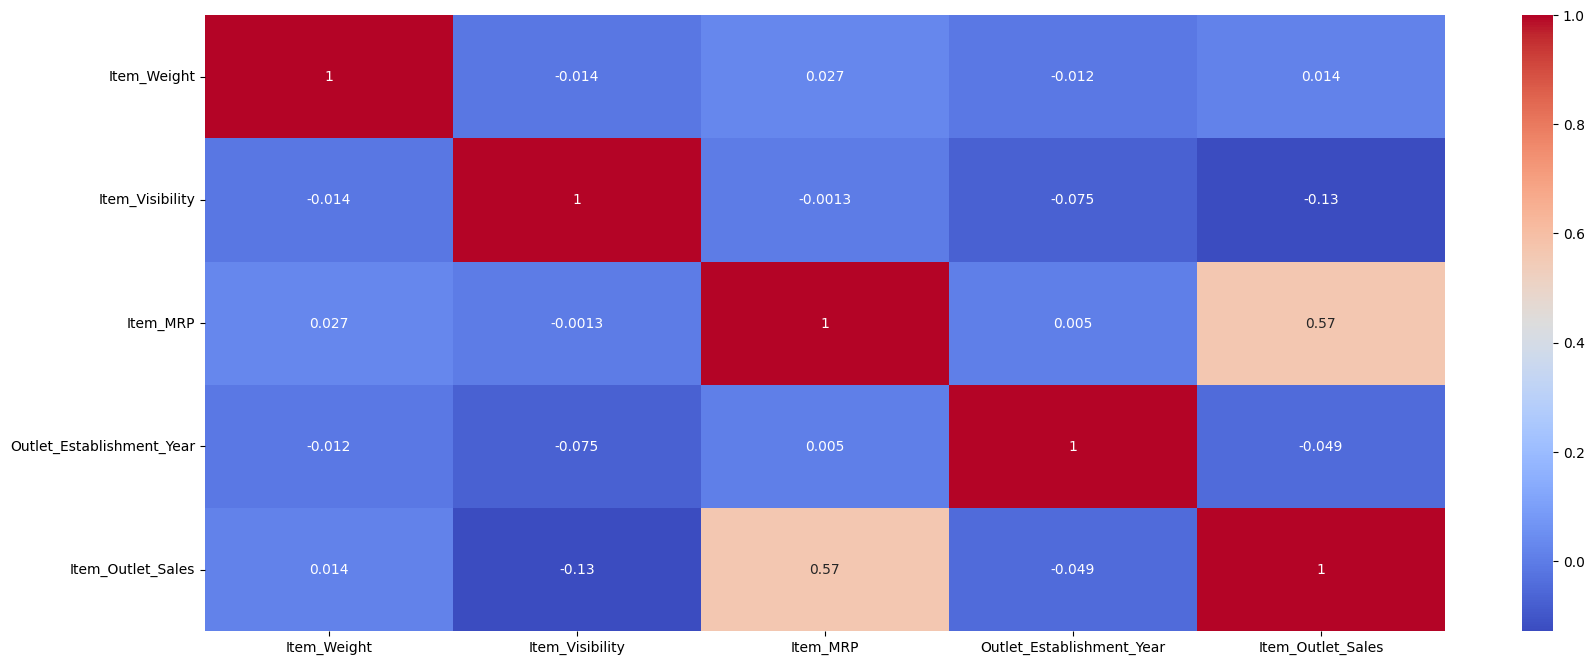

In [15]:
train = train_df.select_dtypes(include=[float, int])
plt.figure(figsize=(20, 8))
sns.heatmap(train.corr(), annot=True, cmap="coolwarm", cbar=True)

In [16]:
x_train = train_df[["Item_Weight", "Item_Visibility", "Item_MRP"]]
x_test = test_df[["Item_Weight", "Item_Visibility", "Item_MRP"]]
y_train = train_df["Item_Outlet_Sales"]

In [17]:
display(x_train.isna().sum())
display(y_train.isna().sum())

Item_Weight        1463
Item_Visibility       0
Item_MRP              0
dtype: int64

np.int64(0)

In [18]:
x_train=x_train.fillna(x_train.mean())
display(x_train.isna().sum())


Item_Weight        0
Item_Visibility    0
Item_MRP           0
dtype: int64

In [23]:
from sklearn.neighbors import KNeighborsRegressor

neigh = KNeighborsRegressor(n_neighbors=15)
neigh.fit(x_train, y_train)

KNeighborsRegressor(n_neighbors=15)

In [24]:
y_pred = neigh.predict(x_train)
PredictDF = train_df.copy()
PredictDF["Item_Outlet_Sales_Predict"] = y_pred
display(y_pred)

array([3639.44034667,  794.56572   , 1959.62694667, ..., 1198.52877333,
       1713.05901333, 1387.57158667], shape=(8523,))

In [25]:
display(PredictDF)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Outlet_Sales_Predict
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,3639.440347
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,794.565720
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,1959.626947
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800,2846.383773
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,875.926480
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834,2976.836187
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850,1419.441213
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136,1198.528773
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976,1713.059013
